In [1]:
# import all essential library

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')


In [2]:
# load dataset Student performance
data = pd.read_csv(r"C:\Users\malvi\Downloads\Student_Performance.csv")
print(data)

      Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0                 7               99                        Yes            9   
1                 4               82                         No            4   
2                 8               51                        Yes            7   
3                 5               52                        Yes            5   
4                 7               75                         No            8   
...             ...              ...                        ...          ...   
9995              1               49                        Yes            4   
9996              7               64                        Yes            8   
9997              6               83                        Yes            8   
9998              9               97                        Yes            7   
9999              7               74                         No            8   

      Sample Question Papers Practiced 

In [3]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [4]:
data.tail

<bound method NDFrame.tail of       Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0                 7               99                        Yes            9   
1                 4               82                         No            4   
2                 8               51                        Yes            7   
3                 5               52                        Yes            5   
4                 7               75                         No            8   
...             ...              ...                        ...          ...   
9995              1               49                        Yes            4   
9996              7               64                        Yes            8   
9997              6               83                        Yes            8   
9998              9               97                        Yes            7   
9999              7               74                         No            8   

      Sam

In [5]:
data.info

<bound method DataFrame.info of       Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0                 7               99                        Yes            9   
1                 4               82                         No            4   
2                 8               51                        Yes            7   
3                 5               52                        Yes            5   
4                 7               75                         No            8   
...             ...              ...                        ...          ...   
9995              1               49                        Yes            4   
9996              7               64                        Yes            8   
9997              6               83                        Yes            8   
9998              9               97                        Yes            7   
9999              7               74                         No            8   

      S

In [6]:
data.shape

(10000, 6)

In [7]:
data.duplicated().sum()

np.int64(127)

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
x = data[['Hours Studied']]
y = data['Performance Index']

In [11]:
x.shape

(9873, 1)

In [12]:
y.shape

(9873,)

In [13]:
from sklearn.model_selection import train_test_split
x_train ,x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

# Method1 : Simple Linear Regration

In [14]:
from sklearn.linear_model import LinearRegression
linear_model =  LinearRegression()
linear_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = linear_model.predict(x_test)
y_pred[:10]


array([52.2923979 , 46.79803498, 46.79803498, 44.05085352, 44.05085352,
       57.78676082, 52.2923979 , 57.78676082, 46.79803498, 60.53394229])

In [16]:
y_test[:10]

823     36
3764    46
9627    53
8507    56
405     48
2872    39
4690    44
9150    81
7701    78
6187    79
Name: Performance Index, dtype: int64

In [17]:
print(linear_model.score(x_test , y_test))
print(linear_model.score(x_train , y_train))

0.14983580293062604
0.13653217755423797


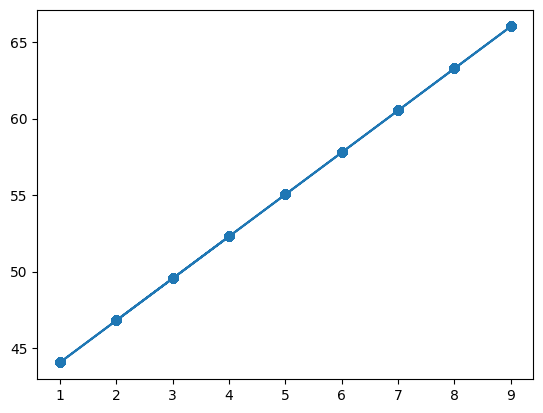

In [18]:
plt.scatter(x_test, y_pred)
plt.plot(x_test, y_pred)

In [19]:
from sklearn.metrics import r2_score
r2_score(x_test, y_pred)

-373.2329301840922

# Method2 : Multiple Linear Regrassion

In [20]:
data.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [21]:
# Feature Encoding

data['Extracurricular Activities'].value_counts()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64

In [22]:
from sklearn.preprocessing import LabelEncoder
lab_encoder = LabelEncoder()
data['Extracurricular Activities'] = lab_encoder.fit_transform(data['Extracurricular Activities'])

In [23]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66


In [24]:
x = data.drop('Performance Index',axis= 1)
y = data['Performance Index']

In [25]:
x_train ,x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

In [26]:
multi_lin_model = LinearRegression()
multi_lin_model.fit(x_test , y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
multi_lin_model = LinearRegression()
multi_lin_model.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = multi_lin_model.predict(x_test)
y_pred[:10]

array([23.64016964, 72.83006391, 42.63098758, 25.4078193 , 51.10657623,
       76.76151103, 33.62677957, 46.68636388, 62.30134091, 70.41052235])

In [29]:
print(multi_lin_model.score(x_test,y_test))
print(multi_lin_model.score(x_test,y_test))

0.9887498895272504
0.9887498895272504


In [30]:
print(r2_score(y_pred,y_test))

0.9886997356485211


In [31]:
print(x_train.shape , y_train.shape)
print(x_test.shape , y_test.shape)

(6911, 5) (6911,)
(2962, 5) (2962,)


In [32]:
# load dataset Salary data
data1 = pd.read_csv(r"C:\Users\malvi\Downloads\salary_data.csv")

In [33]:
data1.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [34]:
data1.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [35]:
data1.info

<bound method DataFrame.info of     YearsExperience  Salary
0               1.1   39343
1               1.3   46205
2               1.5   37731
3               2.0   43525
4               2.2   39891
5               2.9   56642
6               3.0   60150
7               3.2   54445
8               3.2   64445
9               3.7   57189
10              3.9   63218
11              4.0   55794
12              4.0   56957
13              4.1   57081
14              4.5   61111
15              4.9   67938
16              5.1   66029
17              5.3   83088
18              5.9   81363
19              6.0   93940
20              6.8   91738
21              7.1   98273
22              7.9  101302
23              8.2  113812
24              8.7  109431
25              9.0  105582
26              9.5  116969
27              9.6  112635
28             10.3  122391
29             10.5  121872>

In [36]:
x = data1.drop('Salary',axis= 1)
y = data1['Salary']

In [37]:
from sklearn.model_selection import train_test_split
x_train ,x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

In [38]:
x_train ,x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

In [39]:
from sklearn.linear_model import LinearRegression
linear_model =  LinearRegression()
linear_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
multi_lin_model = LinearRegression()
multi_lin_model.fit(x_test , y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
# load dataset manufacturing
data2 = pd.read_csv(r"C:\Users\malvi\Downloads\manufacturing.csv")

In [42]:
data2.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [43]:
data2.tail()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06,99.999975
3956,163.359996,24.332133,3974.897121,41092.392901,4.358913e+06,100.000000


In [44]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [45]:
data2.duplicated().sum()

np.int64(0)

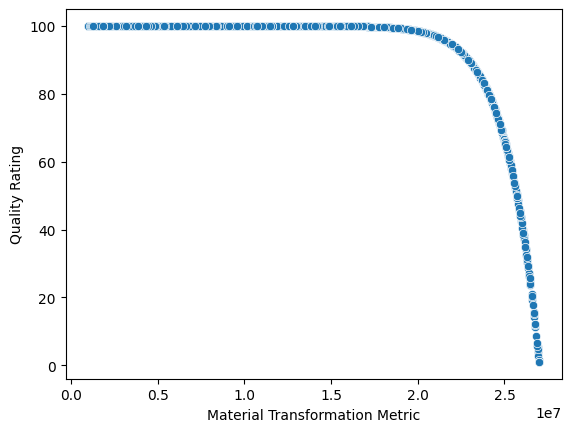

In [46]:
plt.Figure(figsize = (4,3))
sns.scatterplot(x = data2['Material Transformation Metric'], y =data2['Quality Rating'])
plt.xlabel('Material Transformation Metric')
plt.ylabel('Quality Rating')
plt.show()

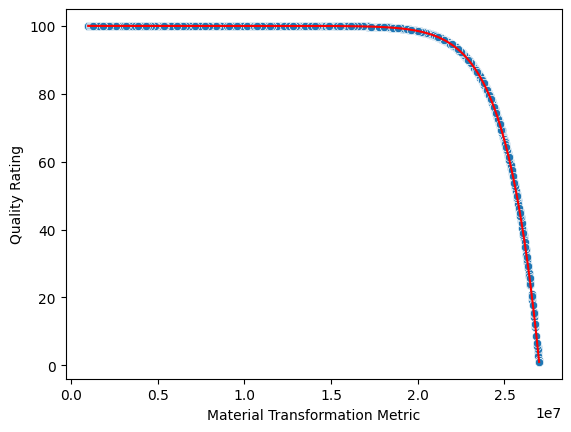

In [47]:
plt.Figure(figsize = (4,3))
sns.scatterplot(x = data2['Material Transformation Metric'], y =data2['Quality Rating'])
sns.lineplot(x = data2['Material Transformation Metric'], y =data2['Quality Rating'], color='red')
plt.xlabel('Material Transformation Metric')
plt.ylabel('Quality Rating')
plt.show()

In [48]:
data2.columns

Index(['Temperature (°C)', 'Pressure (kPa)', 'Temperature x Pressure',
       'Material Fusion Metric', 'Material Transformation Metric',
       'Quality Rating'],
      dtype='object')

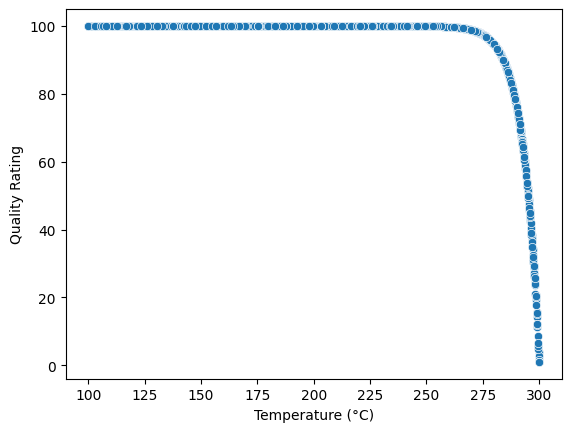

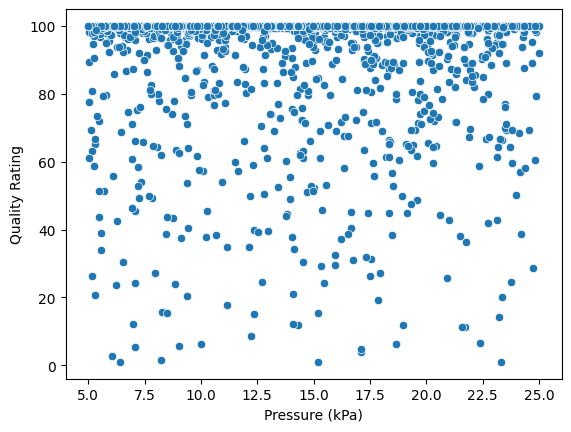

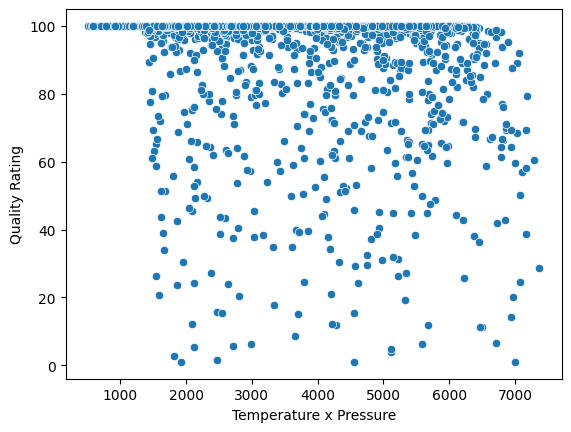

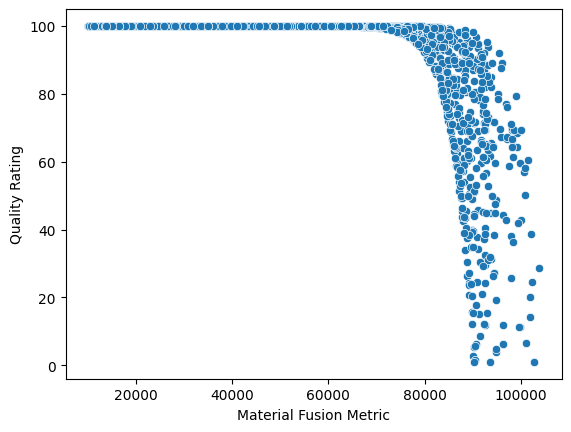

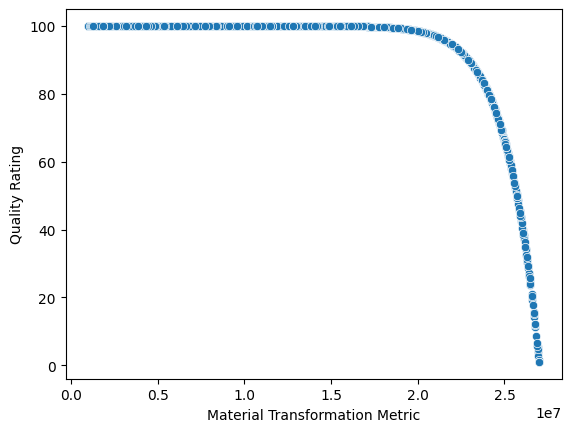

In [49]:
col = ['Temperature (°C)', 'Pressure (kPa)', 'Temperature x Pressure',
       'Material Fusion Metric', 'Material Transformation Metric']

for i in col:
       plt.Figure(figsize = (4,3))
       sns.scatterplot(x = data2[i], y =data2['Quality Rating'])
       plt.xlabel(i)
       plt.ylabel('Quality Rating')
       plt.show()

In [50]:
x = data2.iloc[:,:-1]
y = data2.iloc[:,-1]

In [51]:
x

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06
...,...,...,...,...,...
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06


In [52]:
y

0        99.999971
1        99.985703
2        99.999758
3        99.999975
4       100.000000
           ...    
3952    100.000000
3953     99.999997
3954     99.989318
3955     99.999975
3956    100.000000
Name: Quality Rating, Length: 3957, dtype: float64

In [53]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3)


In [54]:
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(2769, 5) (2769,)
(1188, 5) (1188,)


# Multiple Linear Regression

In [55]:
from sklearn.linear_model import LinearRegression
multi_lin_model = LinearRegression()
multi_lin_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
multi_pred = multi_lin_model.predict(x_test)
multi_pred[:10]

array([ 92.08618921, 103.12839432, 103.37491841, 101.064745  ,
        93.88787618,  93.28434437, 105.33778229,  99.96366918,
        98.49311665, 103.49682197])

In [57]:
y_test[:10]

1946    100.000000
1805    100.000000
1434     99.999997
305     100.000000
1678    100.000000
3866     99.928222
578     100.000000
1794     99.999379
602      99.995788
593      99.999987
Name: Quality Rating, dtype: float64

In [58]:
from sklearn.metrics import r2_score
r2_score(y_test,multi_pred)*100

49.40861966565308

# Polynomial Regresion

In [59]:
from sklearn.preprocessing import PolynomialFeatures
poly_feature =  PolynomialFeatures()
x_poly = poly_feature.fit_transform(x)

In [60]:
x_poly[:5]

array([[1.00000000e+00, 2.09762701e+02, 8.05085537e+00, 1.68876917e+03,
        4.45222171e+04, 9.22957596e+06, 4.40003906e+04, 1.68876917e+03,
        3.54240781e+05, 9.33910050e+06, 1.93602078e+09, 6.48162722e+01,
        1.35960363e+04, 3.58441931e+05, 7.43059812e+07, 2.85194130e+06,
        7.51877474e+07, 1.55866233e+10, 1.98222781e+09, 4.10921184e+11,
        8.51850724e+13],
       [1.00000000e+00, 2.43037873e+02, 1.58120684e+01, 3.84293147e+03,
        6.30207650e+04, 1.43553672e+07, 5.90674078e+04, 3.84293147e+03,
        9.33977891e+05, 1.53164327e+07, 3.48889790e+09, 2.50021506e+02,
        6.07646951e+04, 9.96488645e+05, 2.26988047e+08, 1.47681223e+07,
        2.42184481e+08, 5.51666922e+10, 3.97161682e+09, 9.04686220e+11,
        2.06076566e+14],
       [1.00000000e+00, 2.20552675e+02, 7.84313005e+00, 1.72982331e+03,
        4.91259502e+04, 1.07283887e+07, 4.86434825e+04, 1.72982331e+03,
        3.81517159e+05, 1.08348597e+07, 2.36617483e+09, 6.15146889e+01,
        1.3567

In [61]:
x_poly.shape

(3957, 21)

In [62]:
x_train,x_test , y_train, y_test = train_test_split(x_poly,y, test_size=0.3)

In [63]:
print(x_train.shape , y_train.shape,)
print(x_test.shape , y_test.shape)

(2769, 21) (2769,)
(1188, 21) (1188,)


In [64]:
from sklearn.linear_model import  LinearRegression
poly_model = LinearRegression()
poly_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
poly_pred = poly_model.predict(x_test)
poly_pred[:10]

array([106.48650879,  97.92396075, 100.9259338 ,  99.58014704,
        92.97441569, 103.63495057, 100.25549714, 105.29391991,
        45.31287808, 101.24515793])

In [66]:
r2_score(y_test,poly_pred)

0.8633604421895404